# L4 Pandas III: Aggregation and Grouping

- Aggregation: `.groupby`

- Pivot Tables: `pd.pivot_table`

- Merging Tables: `pd.merge()`

In [2]:
import pandas as pd
import numpy as np

local_filename = "CA.TXT"

field_names = ["State", "Sex", "Year", "Name", "Count"]

babynames = pd.read_csv(
    local_filename,
    header=None,
    names=field_names
)

babynames.head()

,State,Sex,Year,Name,Count
0,CA,F,1910,Mary,295
1,CA,F,1910,Helen,239
2,CA,F,1910,Dorothy,220
3,CA,F,1910,Margaret,163
4,CA,F,1910,Frances,134


## 1 Aggregation

- Sometimes we want to compute on a subset of our data

- Say we wanted to aggregate all rows in babynames for a given year

In [3]:
babynames.groupby("Year")

- It generates a `GroupBy` object, which can be viewed as a grouped sub-df

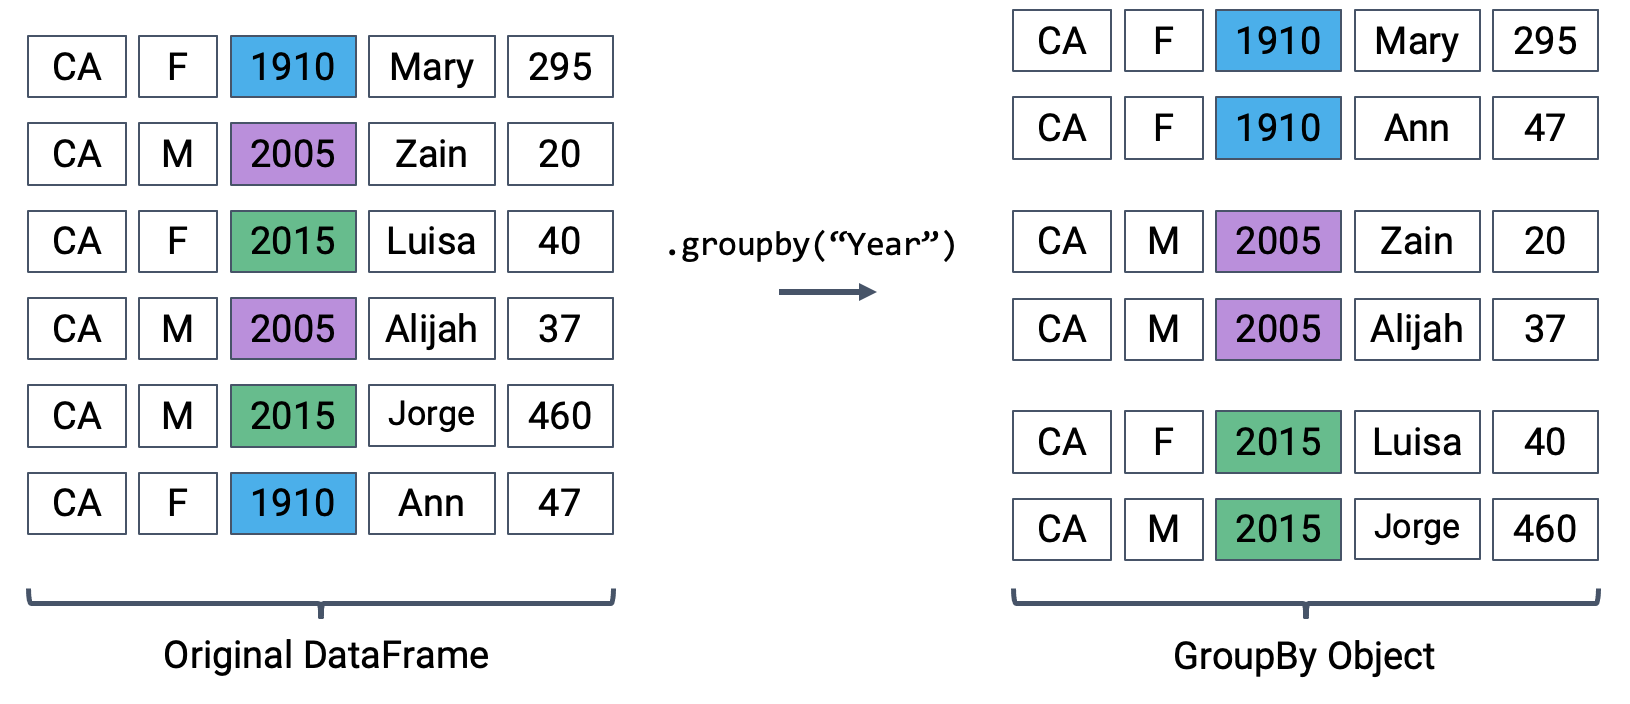

<div style="background-color:#9ca3af30; padding:12px 16px; border-left:5px solid #9ca3af; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Note:</strong> **What happens exactly when calling `.groupby`?**

- When calling `g = df.groupby("Year")`
  
  - No computation happens yet
  
  - Pandas only splits the original df logically
  
```  
  Original df
────────────────────────

1910
┌──────────────┐
│ Mary   295   │
│ Ann     47   │
└──────────────┘

2005
┌──────────────┐
│ Zain    20   │
│ Alijah  37   │
└──────────────┘

2015
┌──────────────┐
│ Luisa   40   │
│ Jorge  460   │
└──────────────┘
```

- Each block is a **group** or a **sub-df**, which is *still a df*

</div>

<div style="background-color:#ef444426; padding:12px 16px; border-left:5px solid #ef4444; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Warning:</strong> 

- We **cannot** work with `GroupBy` object directly

- We need to call aggregation method, which will return a df

</div>

### `.agg()` Method

- It applies to each cols of a **group/sub-df (Input)**

- Then return a new df with one aggregated row per subframe

- Need a **aggregation func** as its parameter (See more below)

**sum**

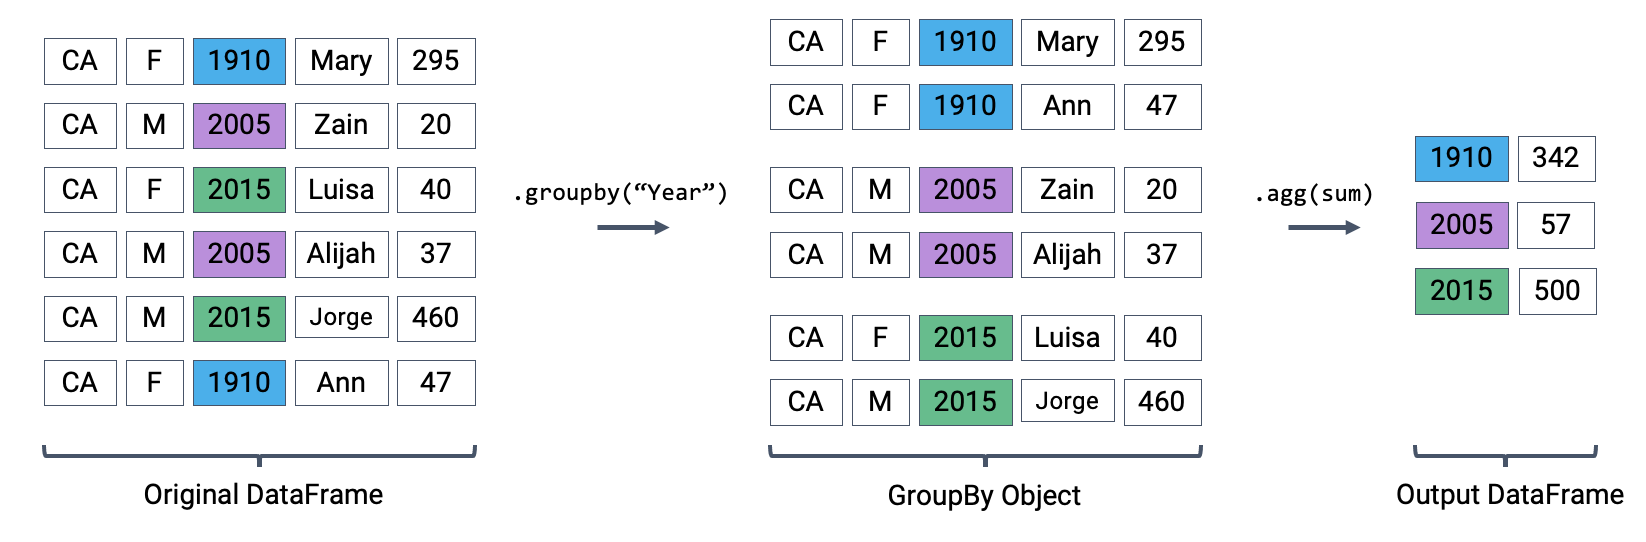

In [ ]:
babynames[["Year", "Count"]].groupby("Year").agg("sum").head(5)

# Calling .agg has condensed each subframe (i.e. group/sub-DataFrame) back into a single row
# This gives us our final output: a DataFrame that is now indexed by "Year"

,Count
Year,
1910,9163
1911,9983
1912,17946
1913,22094
1914,26925


In [7]:
# Same result, but now we explicitly tell pandas to only consider the "Count" column when summing
babynames.groupby("Year")[["Count"]].agg("sum").head(5)

,Count
Year,
1910,9163
1911,9983
1912,17946
1913,22094
1914,26925


**min & max**

In [5]:
babynames[["Year", "Count"]].groupby("Year").agg("min").head(5)

,Count
Year,
1910,5
1911,5
1912,5
1913,5
1914,5


In [6]:
babynames[["Year", "Count"]].groupby("Year").agg("max").head(5)

,Count
Year,
1910,295
1911,390
1912,534
1913,614
1914,773


### Aggregation Functions

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> **Requirements for Aggregation Functions**

- Take in **Series** (One single col)

- **Return a single value** that aggregates this Series

</div>

**In-built Python Operations (`sum`, `max`, `min`)**

In [ ]:
# What is the minimum count for each name in any year?

print(type(babynames.groupby("Name")[["Count"]])) # Type is dfGroupBy object

babynames.groupby("Name")[["Count"]].agg("min").head()

<class 'pandas.core.groupby.generic.DataFrameGroupBy'>


,Count
Name,
Aadan,5
Aadarsh,6
Aaden,10
Aadhav,6
Aadhini,6


In [11]:
# What is the largest single-year count of each name?
babynames.groupby("Name")[["Count"]].agg("max").head()

,Count
Name,
Aadan,7
Aadarsh,6
Aaden,158
Aadhav,8
Aadhini,6


**NumPy Functions**

- `np.mean`, `np.max`, `np.min`, `np.sum`

In [ ]:
# What is the average count for each name across all years?
babynames.groupby("Name")[["Count"]].agg("mean").head() # .agg(np.mean) is also ok

,Count
Name,
Aadan,6.000000
Aadarsh,6.000000
Aaden,46.214286
Aadhav,6.750000
Aadhini,6.000000


<div style="background-color:#8b5cf630; padding:12px 16px; border-left:5px solid #8b5cf6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Question:</strong> **Why we use a string inside `.agg()`?**

- Technically, we should pass in a func, e.g. `.agg(np.min)`

- **Pandas can also refer the functions by taking string names**

- `.agg("sum")`

- `.agg("max")`

- `.agg("min")`

- `.agg("mean")`

- `.agg("first")`

- `.agg("last")`

- `"first"` and `"last"` – are **unique to pandas**
  
  - They return the first or last entry in a subframe column

</div>

- Consider a case where **multiple columns in a group share identical information**

- To represent this information in the grouped output, we simply grab the first or last entry, which will be identical to all other entries

In [13]:
# Imagine we had an additional column, "First Letter". We'll explain this code next week
babynames["First Letter"] = babynames["Name"].str[0]

# We construct a simplified DataFrame containing just a subset of columns
babynames_new = babynames[["Name", "First Letter", "Year"]]
babynames_new.head()

,Name,First Letter,Year
0,Mary,M,1910
1,Helen,H,1910
2,Dorothy,D,1910
3,Margaret,M,1910
4,Frances,F,1910


- We can **use a dictionary to apply different aggregation functions to each column**

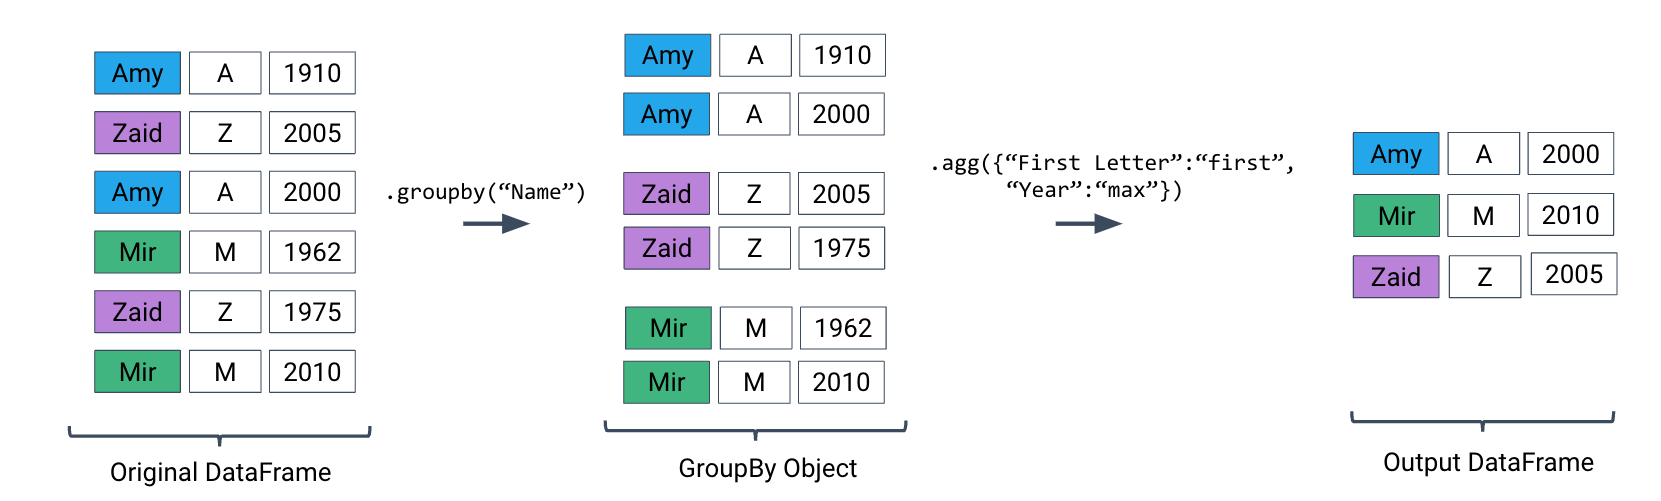

In [14]:
babynames_new.groupby("Name").agg({"First Letter":"first", "Year":"max"}).head()

,First Letter,Year
Name,,
Aadan,A,2014
Aadarsh,A,2019
Aaden,A,2020
Aadhav,A,2019
Aadhini,A,2022


### *Plotting Birth Counts (Exer.)

- Let's find the total number of babies born in each year

- Group by the year and then aggregate using sum

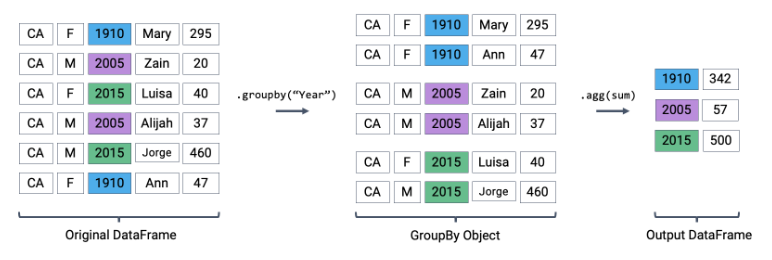

In [15]:
babynames.groupby("Year")[["Count"]].agg(sum).head(5)
# Alternative 1
# babynames.groupby("Year")[["Count"]].sum()
# Alternative 2
# babynames.groupby("Year").sum(numeric_only=True)

/var/folders/2t/f3t7qgfn0b52xhlj1dvj417c0000gn/T/ipykernel_6536/390646742.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  babynames.groupby("Year")[["Count"]].agg(sum).head(5)


,Count
Year,
1910,9163
1911,9983
1912,17946
1913,22094
1914,26925


In [16]:
import plotly.express as px
puzzle2 = babynames.groupby("Year")[["Count"]].agg("sum")
px.line(puzzle2, y = "Count")

<div style="background-color:#ef444426; padding:12px 16px; border-left:5px solid #ef4444; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Warning:</strong> 

We made an enormous assumption when we decided to use this dataset to estimate birth rate. According to [this article from the Legislative Analyst’s Office](https://lao.ca.gov/LAOEconTax/Article/Detail/691), the true number of babies born in California in 2020 was 421,275. However, our plot shows 362,882 babies —— what happened?

</div>

### Summary

`GroupBy` operation entails:

- **Split** df into sub-df by index

- **Apply** a func to each sub-df seperately

- **Combine** the results by index

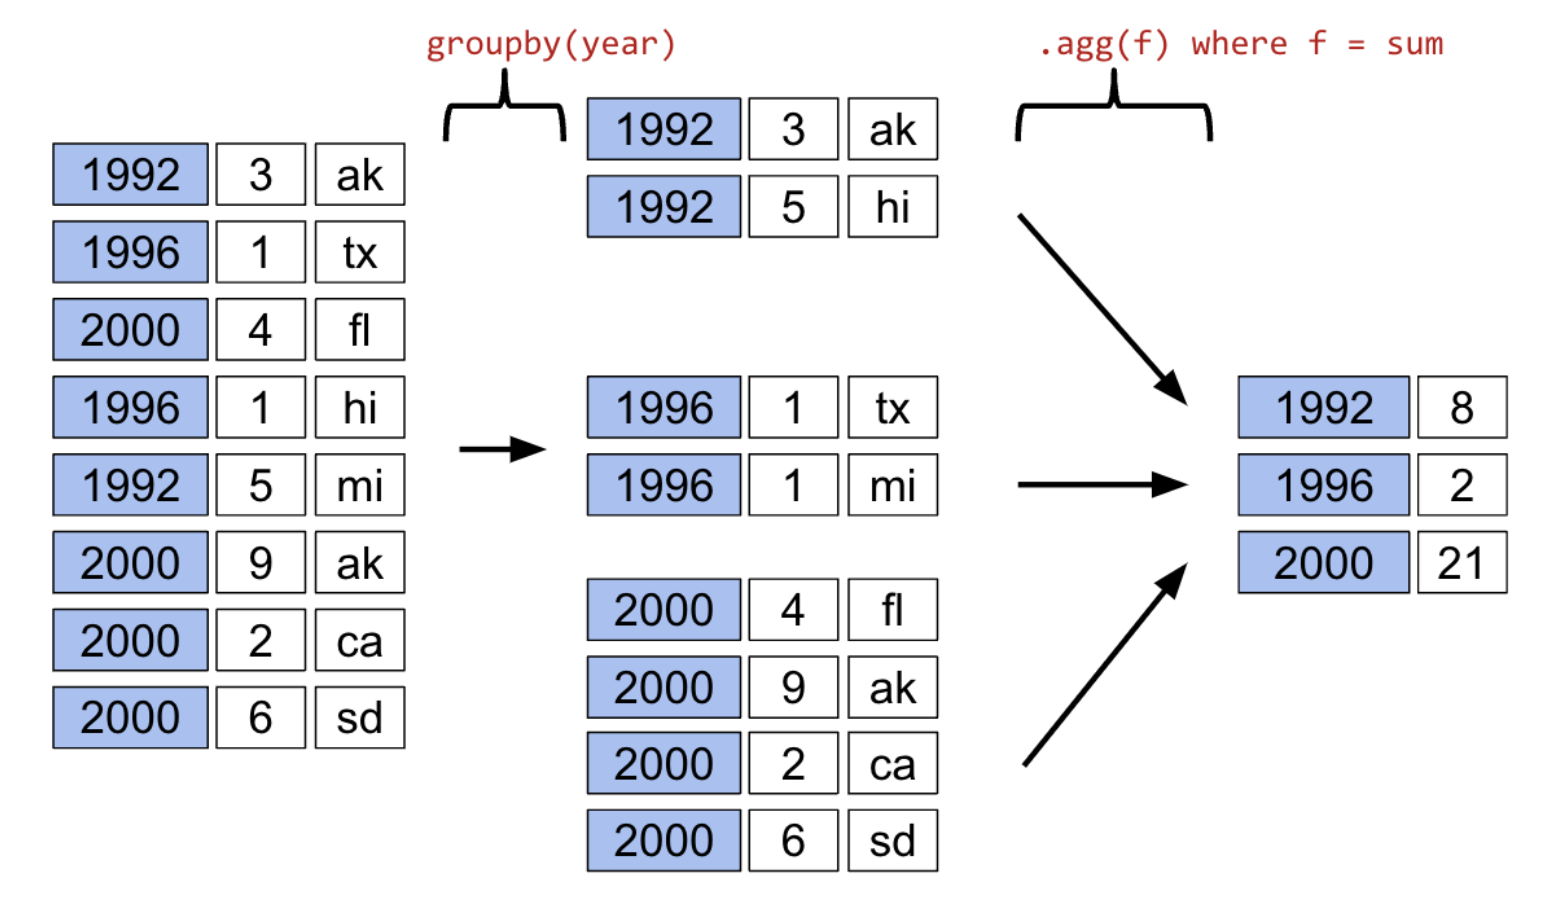

### Revisiting `.agg()` Func

- It can take any funcs than **turns multiple values into one value**

- Some commonly-used aggregation funcs can be **called directly** without using `.agg()` (e.g. `.mean()`)

In [19]:
babynames.groupby("Year").mean().head()

TypeError: agg function failed [how->mean,dtype->object]

- We can **build our own aggregation funcs** (Input: Series, Output: One value)

In [ ]:
# “Ratio to Peak” (RTP) is the ratio of babies born with a given name to the maximum number of babies born with the name in any year
def ratio_to_peak(series):
    return series.iloc[-1] / max(series)

#Using .groupby() to apply the function
rtp_table = f_babynames.groupby("Name")[["Year", "Count"]].agg(ratio_to_peak)
rtp_table.head()

,Year,Count
Name,,
Aadhini,1.0,1.000000
Aadhira,1.0,0.500000
Aadhya,1.0,0.820000
Aadya,1.0,0.827586
Aahana,1.0,0.307692


<div style="background-color:#ef444426; padding:12px 16px; border-left:5px solid #ef4444; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Warning:</strong> **Specific Cols, Not Tables**

- `.agg()` cannot apply to **whole df**, it has to be applied to **Specific Series or df**!

</div>

In [22]:
f_babynames.groupby("Name").agg(ratio_to_peak)

TypeError: unsupported operand type(s) for /: 'str' and 'str'

### Renaming Cols After Grouping

- `.groupby()` won't rename any aggregated cols

In [25]:
def ratio_to_peak(series):
    return series.iloc[-1] / max(series)

rtp_table = f_babynames.groupby("Name")[["Year", "Count"]].agg(ratio_to_peak)
rtp_table.head()

,Year,Count
Name,,
Aadhini,1.0,1.000000
Aadhira,1.0,0.500000
Aadhya,1.0,0.820000
Aadya,1.0,0.827586
Aahana,1.0,0.307692


- The aggregated column is still named Count even though it now represents the RTP

- **Use `.rename()` to rename** (`df.rename(dict)`)

In [26]:
rtp_table = rtp_table.rename(columns = {"Count": "Count RTP"})
rtp_table

,Year,Count RTP
Name,,
Aadhini,1.0,1.000000
Aadhira,1.0,0.500000
Aadhya,1.0,0.820000
Aadya,1.0,0.827586
Aahana,1.0,0.307692
...,...,...
Zyanya,1.0,0.400000
Zyla,1.0,0.742857
Zylah,1.0,0.700000


### *Some Data Science Payoff (Exer.)

In [28]:
# See the names whose popularity has decreased the most
rtp_table = rtp_table.rename(columns = {"Count": "Count RTP"})
rtp_table.sort_values("Count RTP").head()

,Year,Count RTP
Name,,
Debra,1.0,0.001512
Debbie,1.0,0.002818
Karen,1.0,0.003026
Tammy,1.0,0.003247
Diane,1.0,0.003663


In [34]:
import plotly.express as px
px.line(f_babynames[f_babynames["Name"] == "Debra"], x = "Year", y = "Count")

In [33]:
top10 = rtp_table.sort_values("Count RTP").head(10).index
px.line(
    f_babynames[f_babynames["Name"].isin(top10)], 
    x = "Year", 
    y = "Count", 
    color = "Name"
)

In [ ]:
# Compute the total number of babies with each name
babynames.groupby("Name")[["Count"]].agg("sum").head()
# alternative solution: 
# babynames.groupby("Name")[["Count"]].sum()

,Count
Name,
Aadan,18
Aadarsh,6
Aaden,647
Aadhav,27
Aadhini,6


### Revisitiing `.groupby()`

In [37]:
import pandas as pd
import numpy as np

elections = pd.read_csv("elections.csv")
elections.head(5)

,Year,Candidate,Party,Popular vote,Result,%
0,1824,Andrew Jackson,Democratic-Republican,151271,loss,57.210122
1,1824,John Quincy Adams,Democratic-Republican,113142,win,42.789878
2,1828,Andrew Jackson,Democratic,642806,win,56.203927
3,1828,John Quincy Adams,National Republican,500897,loss,43.796073
4,1832,Andrew Jackson,Democratic,702735,win,54.574789


- The result of groupby applied to a DataFrame is a **DataFrameGroupBy** object, **not a DataFrame**

In [38]:
grouped_by_year = elections.groupby("Year")
type(grouped_by_year)

pandas.core.groupby.generic.DataFrameGroupBy

- There are some ways to look into **DataFrameGroupBy** objects

**`.groups` Attribute**

In [ ]:
# Show the dfgroupby in the form of a dict
grouped_by_party = elections.groupby("Party")
grouped_by_party.groups

{'American': [22, 126], 'American Independent': [115, 119, 124], 'Anti-Masonic': [6], 'Anti-Monopoly': [38], 'Citizens': [127], 'Communist': [89], 'Constitution': [160, 164, 172], 'Constitutional Union': [24], 'Democratic': [2, 4, 8, 10, 13, 14, 17, 20, 28, 29, 34, 37, 39, 45, 47, 52, 55, 57, 64, 70, 74, 77, 81, 83, 86, 91, 94, 97, 100, 105, 108, 111, 114, 116, 118, 123, 129, 134, 137, 140, 144, 151, 158, 162, 168, 176, 178, 183], 'Democratic-Republican': [0, 1], 'Dixiecrat': [103], 'Farmer–Labor': [78], 'Free Soil': [15, 18], 'Green': [149, 155, 156, 165, 170, 177, 181, 184], 'Greenback': [35], 'Independent': [121, 130, 143, 161, 167, 174, 185], 'Liberal Republican': [31], 'Libertarian': [125, 128, 132, 138, 139, 146, 153, 159, 163, 169, 175, 180], 'Libertarian Party': [186], 'National Democratic': [50], 'National Republican': [3, 5], 'National Union': [27], 'Natural Law': [148], 'New Alliance': [136], 'Northern Democratic': [26], 'Populist': [48, 61, 141], 'Progressive': [68, 82, 101

**`.get_group()` Method**

In [40]:
# Input an index to extract the specific sub-df (a df)
grouped_by_party.get_group("Socialist")

,Year,Candidate,Party,Popular vote,Result,%
58,1904,Eugene V. Debs,Socialist,402810,loss,2.985897
62,1908,Eugene V. Debs,Socialist,420852,loss,2.850866
66,1912,Eugene V. Debs,Socialist,901551,loss,6.004354
71,1916,Allan L. Benson,Socialist,590524,loss,3.194193
76,1920,Eugene V. Debs,Socialist,913693,loss,3.428282
85,1928,Norman Thomas,Socialist,267478,loss,0.728623
88,1932,Norman Thomas,Socialist,884885,loss,2.236211
92,1936,Norman Thomas,Socialist,187910,loss,0.412876
95,1940,Norman Thomas,Socialist,116599,loss,0.234237
102,1948,Norman Thomas,Socialist,139569,loss,0.286312


### *Other GroupBy Methods (Exer.)

In [ ]:
# Given
df = pd.DataFrame({'letter':['A','A','B','C','C','C'], 
                   'num':[1,2,3,4,np.nan,4], 
                   'state':[np.nan, 'tx', 'fl', 'hi', np.nan, 'ak']})
df

,letter,num,state
0,A,1.0,NaN
1,A,2.0,tx
2,B,3.0,fl
3,C,4.0,hi
4,C,NaN,NaN
5,C,4.0,ak


In [ ]:
# It counts how many entries
df.groupby("letter").size()

letter
A    2
B    1
C    3
dtype: int64

In [ ]:
# It counts how many values (exclude missing values)
df.groupby("letter").count()

,num,state
letter,,
A,2,1
B,1,1
C,2,2


In [ ]:
# value_counts() and groupby.size() are the same
# Except value_counts() sorts the resulting Series in descending order automatically
df["letter"].value_counts()

letter
C    3
A    2
B    1
Name: count, dtype: int64

### Filtering By group

`groupby.filter` applies a func whose:

- Input: **DataFrame**

- Output: `True` or `False`

**to each sub-df**, then:

- If `True`, **keep all rows of that sub-df**

- If` false`, filter out all rows

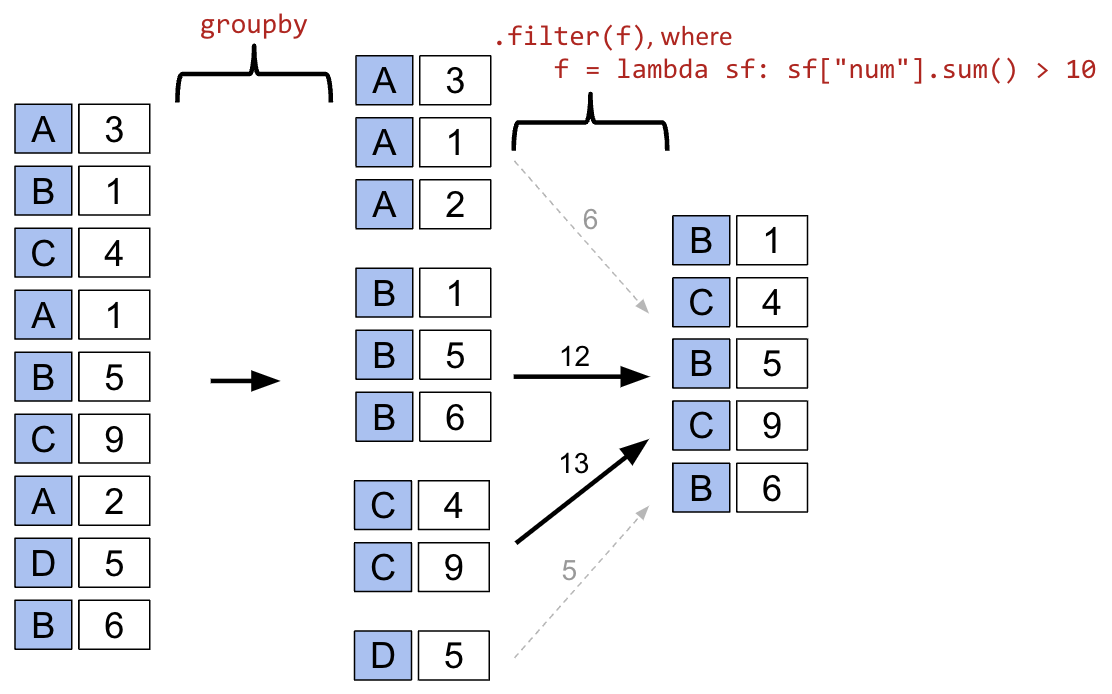

<div style="background-color:#8b5cf630; padding:12px 16px; border-left:5px solid #8b5cf6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Question:</strong> **How is the `groupby.filter` procedure different to the **boolean filtering** we’ve seen previously?**

- Boolean filtering considers **individual** rows

- `groupby.filter` applies a boolean condition **across all rows in a group**
  
  -  If one row doesn't satisfy the condition, all other rows in this group will be discarded

</div>

### Aggregation with `lambda` Funcs

In [46]:
elections_sorted_by_percent = elections.sort_values("%", ascending=False)
elections_sorted_by_percent.head(5)

,Year,Candidate,Party,Popular vote,Result,%
114,1964,Lyndon Johnson,Democratic,43127041,win,61.344703
91,1936,Franklin Roosevelt,Democratic,27752648,win,60.978107
120,1972,Richard Nixon,Republican,47168710,win,60.907806
79,1920,Warren Harding,Republican,16144093,win,60.574501
133,1984,Ronald Reagan,Republican,54455472,win,59.023326


In [ ]:
# Sorting elections by descending order of % then group by Party
elections_sorted_by_percent.groupby("Party").agg(lambda x : x.iloc[0]).head(10)

# Equivalent to the below code
# elections_sorted_by_percent.groupby("Party").agg('first').head(10)

,Year,Candidate,Popular vote,Result,%
Party,,,,,
American,1856,Millard Fillmore,873053,loss,21.554001
American Independent,1968,George Wallace,9901118,loss,13.571218
Anti-Masonic,1832,William Wirt,100715,loss,7.821583
Anti-Monopoly,1884,Benjamin Butler,134294,loss,1.335838
Citizens,1980,Barry Commoner,233052,loss,0.270182
Communist,1932,William Z. Foster,103307,loss,0.261069
Constitution,2008,Chuck Baldwin,199750,loss,0.152398
Constitutional Union,1860,John Bell,590901,loss,12.639283
Democratic,1964,Lyndon Johnson,43127041,win,61.344703


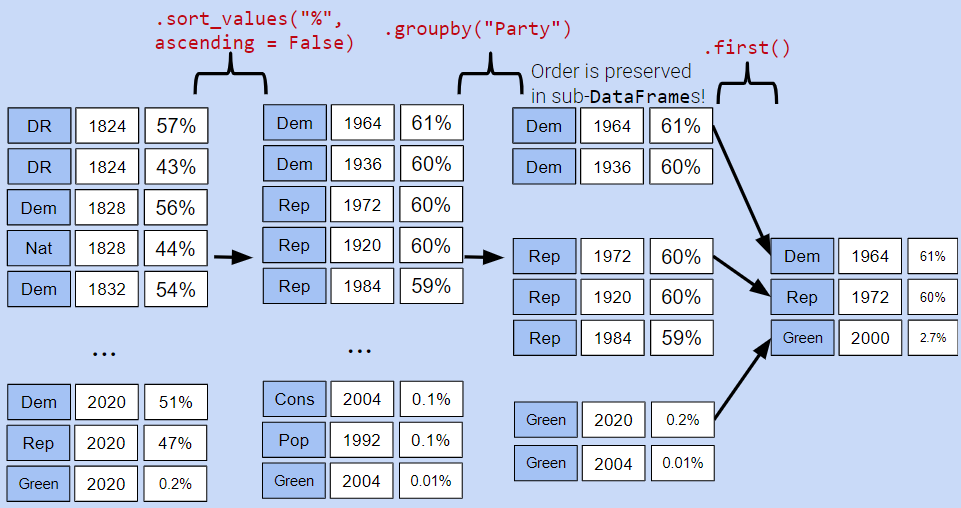

## 2 Pivot Tables

- Examples above are all for one col
  
- It is also possible to apply for **multiple cols** at once

**e.g.** find the total number of baby names associated with each sex for each year

In [48]:
babynames.head()

,State,Sex,Year,Name,Count,First Letter
0,CA,F,1910,Mary,295,M
1,CA,F,1910,Helen,239,H
2,CA,F,1910,Dorothy,220,D
3,CA,F,1910,Margaret,163,M
4,CA,F,1910,Frances,134,F


- Need to be grouped by Sex & Year (Ricardian Product)

In [49]:
# Find the total number of baby names associated with each sex for each 
# year in the data
babynames.groupby(["Year", "Sex"])[["Count"]].agg("sum").head(6)

Count
Year Sex       
1910 F     5950
     M     3213
1911 F     6602
     M     3381
1912 F     9804
     M     8142

- We’ve created a **multi-index** DataFrame where two different index values, the year and sex, are used to uniquely identify each row

- But this is difficult to use if the df has multiple dimensions

- We can use **Pivot Table (数据透视表)** to solve it

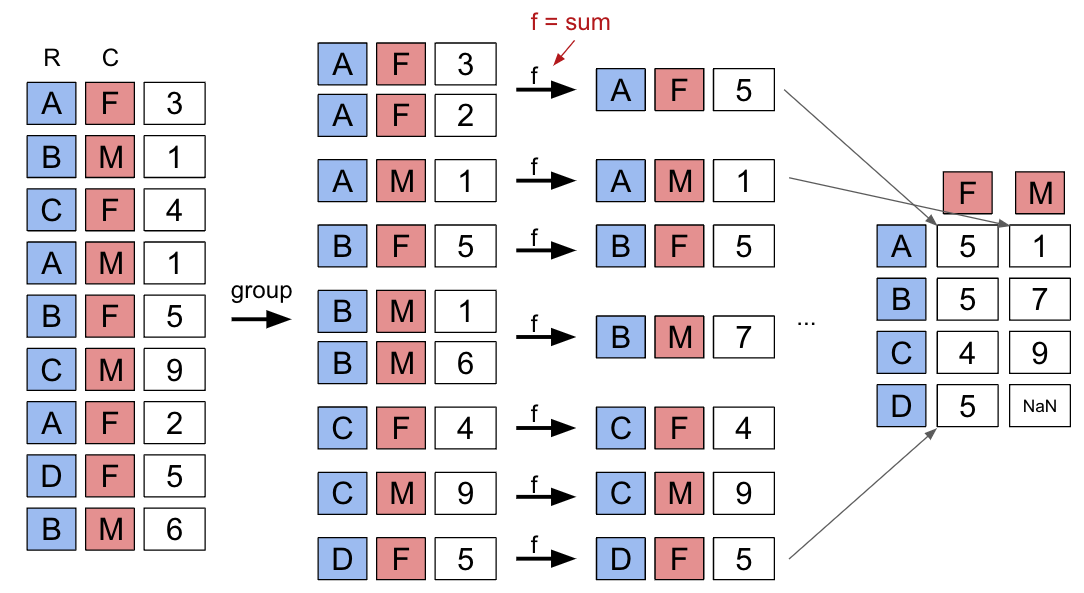

In [50]:
# The `pivot_table` method is used to generate a Pandas pivot table
import numpy as np
babynames.pivot_table(
    index = "Year", # For rows
    columns = "Sex", # For cols    
    values = "Count", # For elements
    aggfunc = "sum", # For funcs
).head(5)

Sex,F,M
Year,,
1910,5950,3213
1911,6602,3381
1912,9804,8142
1913,11860,10234
1914,13815,13110


| **Sex** | **F** | **M** |
| --- | --- | --- |
| **Year** |  |  |
| **1910** | 5950 | 3213 |
| **1911** | 6602 | 3381 |
| **1912** | 9804 | 8142 |
| **1913** | 11860 | 10234 |
| **1914** | 13815 | 13111 |

In [51]:
babynames_pivot = babynames.pivot_table(
    index="Year",     # the rows (turned into index)
    columns="Sex",    # the column values
    values=["Count", "Name"], 
    aggfunc="max",      # group operation
)
babynames_pivot.head(6)

Count          Name         
Sex      F     M       F        M
Year                             
1910   295   237  Yvonne  William
1911   390   214   Zelma   Willis
1912   534   501  Yvonne  Woodrow
1913   584   614   Zelma   Yoshio
1914   773   769   Zelma   Yoshio
1915   998  1033    Zita    Yukio

|  | **Count** |  | **Name** |  |
| --- | --- | --- | --- | --- |
| **Sex** | **F** | **M** | **F** | **M** |
| **Year** |  |  |  |  |
| **1910** | 295 | 237 | Yvonne | William |
| **1911** | 390 | 214 | Zelma | Willis |
| **1912** | 534 | 501 | Yvonne | Woodrow |
| **1913** | 584 | 614 | Zelma | Yoshio |
| **1914** | 773 | 769 | Zelma | Yoshio |
| **1915** | 998 | 1033 | Zita | Yukio |

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> 

- When you just select one value, it won't show the name for the col

- When it is above 2 cols, it will show

</div>

## 3 Merging Tables

- A real world data project needs you to grapple data from multiple sources

- So you may need to **combine multiple tables together**

In [52]:
elections.head(5)

,Year,Candidate,Party,Popular vote,Result,%
0,1824,Andrew Jackson,Democratic-Republican,151271,loss,57.210122
1,1824,John Quincy Adams,Democratic-Republican,113142,win,42.789878
2,1828,Andrew Jackson,Democratic,642806,win,56.203927
3,1828,John Quincy Adams,National Republican,500897,loss,43.796073
4,1832,Andrew Jackson,Democratic,702735,win,54.574789


In [53]:
babynames.head(5)

,State,Sex,Year,Name,Count,First Letter
0,CA,F,1910,Mary,295,M
1,CA,F,1910,Helen,239,H
2,CA,F,1910,Dorothy,220,D
3,CA,F,1910,Margaret,163,M
4,CA,F,1910,Frances,134,F


- Say we want to understand the popularity of the names of each presidential candidate in 2022

- We need to merge the **Candidate** in  `elections` & **Name** in `babynames`

- To merge, **2 tables need to have relations** to make sense

In [54]:
# This `str` operation splits each candidate's full name at each 
# blank space, then takes just the candidate's first name
elections["First Name"] = elections["Candidate"].str.split().str[0]
elections.head(5)

,Year,Candidate,Party,Popular vote,Result,%,First Name
0,1824,Andrew Jackson,Democratic-Republican,151271,loss,57.210122,Andrew
1,1824,John Quincy Adams,Democratic-Republican,113142,win,42.789878,John
2,1828,Andrew Jackson,Democratic,642806,win,56.203927,Andrew
3,1828,John Quincy Adams,National Republican,500897,loss,43.796073,John
4,1832,Andrew Jackson,Democratic,702735,win,54.574789,Andrew


In [55]:
# Here, we'll only consider `babynames` data from 2022
babynames_2022 = babynames[babynames["Year"]==2022]
babynames_2022.head()

,State,Sex,Year,Name,Count,First Letter
235900,CA,F,2022,Olivia,2190,O
235901,CA,F,2022,Emma,2090,E
235902,CA,F,2022,Camila,2051,C
235903,CA,F,2022,Mia,1893,M
235904,CA,F,2022,Sophia,1773,S


### `pd.merge`

In [ ]:
# Specify 2 tables and corresponding cols
merged = pd.merge(left = elections, right = babynames_2022, \
                  left_on = "First Name", right_on = "Name")
merged.head()

# Notice that pandas automatically specifies `Year_x` and `Year_y` 
# when both merged DataFrames have the same column name to avoid confusion

# Second option, which treats the table calling the method as left table by default
# merged = elections.merge(right = babynames_2022, \
    # left_on = "First Name", right_on = "Name")

,Year_x,Candidate,Party,Popular vote,Result,%,First Name,State,Sex,Year_y,Name,Count,First Letter
0,1824,Andrew Jackson,Democratic-Republican,151271,loss,57.210122,Andrew,CA,M,2022,Andrew,748,A
1,1824,John Quincy Adams,Democratic-Republican,113142,win,42.789878,John,CA,M,2022,John,496,J
2,1828,Andrew Jackson,Democratic,642806,win,56.203927,Andrew,CA,M,2022,Andrew,748,A
3,1828,John Quincy Adams,National Republican,500897,loss,43.796073,John,CA,M,2022,John,496,J
4,1832,Andrew Jackson,Democratic,702735,win,54.574789,Andrew,CA,M,2022,Andrew,748,A


- The detailed pairing rule (Pairing Keys) will be discussed in Lec 5

---
[Reference](https://ds100.org/course-notes/pandas-3/)